# Notebook 1 — Approach A: Temporal Convolutional Network (TCN) with Monte Carlo Dropout

**Course:** Wireless Networks · IIITDM Kancheepuram  
**Team:** Cupcake (Team 5) — CS23B2043 · CS23B1085 · CS23B1004 · CS23I1041  
**Research Gaps Addressed:** Gap 1 (Proactive Load Balancing), Gap 2 (TTC Regression), Gap 3 (Confidence-Aware Decisions)

## What This Notebook Does
1. Loads the synthetic parquet splits (train / val / test) — drops rows where `ttc = NaN`
2. Constructs sliding-window sequences (`seq_len=10`) per AP, chronologically
3. Defines a TCN with dilated convolutions (rates 1, 2, 4) + GlobalAvgPool + Dense head
4. Trains with Huber loss + AdamW + cosine annealing + early stopping on val MAE
5. Performs MC Dropout inference (T=50 stochastic passes) to extract mean + std
6. Evaluates MAE, RMSE, R², uncertainty calibration, and prediction-interval coverage
7. Visualises predictions with uncertainty bands
8. Saves `model_a.pt` and `metrics_a.json`

In [57]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sohanuuu/synthetic-from-crawdad/train.parquet
/kaggle/input/datasets/sohanuuu/synthetic-from-crawdad/test.parquet
/kaggle/input/datasets/sohanuuu/synthetic-from-crawdad/val.parquet


## Section 0 — Environment & Imports

In [86]:
# ── Standard library ────────────────────────────────────────────────────────
import json
import math
import os
import random
import time
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Scientific stack ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# ── Deep learning ────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# ── Utilities ─────────────────────────────────────────────────────────────────
from tqdm.auto import tqdm

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')

PyTorch 2.10.0+cu128 | Device: cuda


## Section 1 — Configuration

In [87]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = Path('/kaggle/input/datasets/sohanuuu/synthetic-from-crawdad')
if not DATA_DIR.exists():
    DATA_DIR = Path('../processed')
    print(f'[INFO] Using local fallback: {DATA_DIR.resolve()}')

OUTPUT_DIR = Path('.')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Sequence construction ──────────────────────────────────────────────────────
SEQ_LEN = 20          # 10 minutes of history

# ── Feature columns ────────────────────────────────────────────────────────────
BASE_FEATURES = [
    'clients_connected',
    'clients_delta',
    'hour_of_day',
    'day_of_week',
    'channel_utilization',
    'neighbor_avg_load',
    'clients_lag1',
    'clients_lag2',
    'clients_roll5_mean',
    'clients_roll5_std',
    'util_rate_of_change',
]
N_FEATURES = len(BASE_FEATURES)   # 11
TARGET_COL = 'ttc'

# ── TCN architecture ───────────────────────────────────────────────────────────
TCN_FILTERS   = 64
TCN_KERNEL    = 3
TCN_DILATIONS = [1, 2, 4]
BLOCK_DROPOUT = 0.3        # Point 7: reduced from 0.3, avoids underfitting
MC_DROPOUT    = 0.2        # kept same for MC uncertainty passes
DROPOUT_RATE  = MC_DROPOUT

# ── Training ───────────────────────────────────────────────────────────────────
BATCH_SIZE   = 256
LR_INIT      = 3e-4       # Point 8: increased from 3e-4 to escape early plateau
WEIGHT_DECAY = 1e-3
MAX_EPOCHS   = 150
PATIENCE     = 15
HUBER_DELTA  = 1.0

# ── MC Dropout ─────────────────────────────────────────────────────────────────
MC_PASSES = 50

# ── Calibration ────────────────────────────────────────────────────────────────
COVERAGE_LEVEL = 0.90

print('Configuration loaded.')
print(f'  SEQ_LEN={SEQ_LEN}, N_FEATURES={N_FEATURES}, TCN_DILATIONS={TCN_DILATIONS}')
print(f'  TCN_FILTERS={TCN_FILTERS}, BLOCK_DROPOUT={BLOCK_DROPOUT}, LR={LR_INIT}')
print(f'  BATCH_SIZE={BATCH_SIZE}, MAX_EPOCHS={MAX_EPOCHS}, MC_PASSES={MC_PASSES}')


Configuration loaded.
  SEQ_LEN=20, N_FEATURES=11, TCN_DILATIONS=[1, 2, 4]
  TCN_FILTERS=64, BLOCK_DROPOUT=0.3, LR=0.0003
  BATCH_SIZE=256, MAX_EPOCHS=150, MC_PASSES=50


## Section 2 — Load & Preprocess Data

In [88]:
def load_split(split: str, data_dir) -> pd.DataFrame:
    """Load a parquet split, drop rows where ttc is NaN, and sort by ap_id+timestamp."""
    path = data_dir / f'{split}.parquet'
    df = pd.read_parquet(path)
    before = len(df)
    df = df.dropna(subset=['ttc']).reset_index(drop=True)
    after = len(df)
    print(f'  [{split}] Loaded {before:,} rows → dropped {before-after:,} NaN-ttc → {after:,} rows')
    return df


def engineer_features(df: pd.DataFrame, boundary_df: pd.DataFrame = None) -> pd.DataFrame:
    """Add lag features per AP (clients_lag1, clients_lag2).

    Parameters
    ----------
    df : DataFrame for this split (train / val / test)
    boundary_df : Optional DataFrame containing the *last 2 rows per AP* from the
                  immediately preceding split.  When provided, lag computation
                  seeds correctly instead of defaulting to 0 for the first rows.
    """
    df = df.sort_values(['ap_id', 'timestamp']).reset_index(drop=True)

    if boundary_df is not None:
        # Tag boundary rows so we can reliably drop them after sort+concat
        boundary_df = boundary_df.copy()
        boundary_df['_is_boundary'] = True
        df['_is_boundary'] = False
        combined = pd.concat([boundary_df, df], ignore_index=True)
        combined = combined.sort_values(['ap_id', 'timestamp']).reset_index(drop=True)
        grp = combined.groupby('ap_id')['clients_connected']
        combined['clients_lag1'] = grp.shift(1).fillna(0)
        combined['clients_lag2'] = grp.shift(2).fillna(0)
        # Drop boundary rows using the marker (safe after any sort order)
        df = combined[~combined['_is_boundary']].drop(columns='_is_boundary').reset_index(drop=True)
    else:
        grp = df.groupby('ap_id')['clients_connected']
        df['clients_lag1'] = grp.shift(1).fillna(0)
        df['clients_lag2'] = grp.shift(2).fillna(0)

    return df


def get_boundary_rows(df: pd.DataFrame, n: int = 2) -> pd.DataFrame:
    """Return the last `n` rows per AP from df (used to seed lag features)."""
    return (
        df.sort_values(['ap_id', 'timestamp'])
          .groupby('ap_id')
          .tail(n)
          .reset_index(drop=True)
    )


print('Loading synthetic parquet splits...')
train_raw = load_split('train', DATA_DIR)
val_raw   = load_split('val',   DATA_DIR)
test_raw  = load_split('test',  DATA_DIR)

# Chronological ordering assertion
if 'timestamp' in train_raw.columns:
    assert train_raw['timestamp'].max() < val_raw['timestamp'].min(), \
        'Train/val temporal leak detected!'
    assert val_raw['timestamp'].max() < test_raw['timestamp'].min(), \
        'Val/test temporal leak detected!'
    print('\n✓ Temporal ordering assertions passed.')

# Engineer lag features — pass boundary rows to avoid zero-padding leak at split edges
print('\nEngineering lag features...')
train_df = engineer_features(train_raw)                               # no predecessor
train_boundary = get_boundary_rows(train_raw, n=2)
val_df   = engineer_features(val_raw,  boundary_df=train_boundary)   # seeded from train
val_boundary   = get_boundary_rows(val_raw,   n=2)
test_df  = engineer_features(test_raw, boundary_df=val_boundary)     # seeded from val

print(f'\nTTC distribution (train):')
print(train_df[TARGET_COL].describe().round(3))


Loading synthetic parquet splits...
  [train] Loaded 1,857,449 rows → dropped 1,837,926 NaN-ttc → 19,523 rows
  [val] Loaded 419,629 rows → dropped 412,058 NaN-ttc → 7,571 rows
  [test] Loaded 218,011 rows → dropped 217,693 NaN-ttc → 318 rows

✓ Temporal ordering assertions passed.

Engineering lag features...

TTC distribution (train):
count    19523.000
mean        27.814
std         18.511
min          0.000
25%         11.000
50%         27.000
75%         44.000
max         60.000
Name: ttc, dtype: float64


## Section 3 — Feature Scaling

In [89]:
# ── Extra feature engineering (rolling stats + util rate-of-change) ───────────
def add_extra_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add rolling statistics and rate-of-change features per AP."""
    df = df.sort_values(["ap_id", "timestamp"]).reset_index(drop=True)
    grp = df.groupby("ap_id")

    # Rolling mean and std of clients_connected over last 5 steps
    df["clients_roll5_mean"] = (
        grp["clients_connected"]
        .transform(lambda x: x.rolling(5, min_periods=1).mean())
    )
    df["clients_roll5_std"] = (
        grp["clients_connected"]
        .transform(lambda x: x.rolling(5, min_periods=1).std().fillna(0))
    )
    # Rate of change of channel_utilization (t vs t-1)
    df["util_rate_of_change"] = (
        grp["channel_utilization"]
        .transform(lambda x: x.diff().fillna(0))
    )
    return df

print("Adding extra features...")
train_df = add_extra_features(train_df)
val_df   = add_extra_features(val_df)
test_df  = add_extra_features(test_df)

# ── Log1p-transform the target (ttc is right-skewed) ─────────────────────────
# We work on log1p(ttc) throughout; final metrics are inverse-transformed.
LOG_TARGET = True
def transform_target(arr):
    return np.log1p(arr) if LOG_TARGET else arr
def inverse_target(arr):
    return np.expm1(arr) if LOG_TARGET else arr

# ── Fit scaler on training data only ─────────────────────────────────────────
scaler_X = StandardScaler()
scaler_y = StandardScaler()

train_X_scaled = scaler_X.fit_transform(train_df[BASE_FEATURES].values.astype(np.float32))
val_X_scaled   = scaler_X.transform(val_df[BASE_FEATURES].values.astype(np.float32))
test_X_scaled  = scaler_X.transform(test_df[BASE_FEATURES].values.astype(np.float32))

train_ttc_log = transform_target(train_df[[TARGET_COL]].values.astype(np.float32))
val_ttc_log   = transform_target(val_df[[TARGET_COL]].values.astype(np.float32))
test_ttc_log  = transform_target(test_df[[TARGET_COL]].values.astype(np.float32))

train_y_scaled = scaler_y.fit_transform(train_ttc_log).ravel()
val_y_scaled   = scaler_y.transform(val_ttc_log).ravel()
test_y_scaled  = scaler_y.transform(test_ttc_log).ravel()

# ── Rebuild DataFrames for sequence construction ───────────────────────────────
def make_scaled_df(df_orig, X_scaled, y_scaled):
    out = pd.DataFrame(X_scaled, columns=BASE_FEATURES)
    out["ttc_scaled"] = y_scaled
    out["ap_id"]      = df_orig["ap_id"].values
    out["timestamp"]  = df_orig["timestamp"].values
    return out

train_scaled = make_scaled_df(train_df, train_X_scaled, train_y_scaled)
val_scaled   = make_scaled_df(val_df,   val_X_scaled,   val_y_scaled)
test_scaled  = make_scaled_df(test_df,  test_X_scaled,  test_y_scaled)

print("Feature means (train, after scaling):", train_X_scaled.mean(axis=0).round(3))
print(f"Target log1p mean (train): {train_y_scaled.mean():.4f}  std: {train_y_scaled.std():.4f}")


Adding extra features...
Feature means (train, after scaling): [ 0. -0. -0.  0. -0. -0.  0.  0. -0.  0.  0.]
Target log1p mean (train): 0.0000  std: 1.0000


## Section 4 — Sliding-Window Sequence Construction

In [90]:
def build_sequences(
    df: pd.DataFrame,
    seq_len: int = SEQ_LEN,
    feature_cols: list = BASE_FEATURES,
    target_col: str = 'ttc_scaled',
) -> tuple:
    """
    Construct sliding-window sequences per AP.

    For each AP, sort by timestamp and extract windows of length `seq_len`.
    The label is the *last* time step's scaled TTC.

    Returns:
        X: np.ndarray of shape (N, seq_len, n_features)
        y: np.ndarray of shape (N,)
    """
    X_list, y_list = [], []

    for ap_id, grp in df.groupby('ap_id', sort=False):
        grp = grp.sort_values('timestamp').reset_index(drop=True)
        feats = grp[feature_cols].values  # (T, F)
        targets = grp[target_col].values  # (T,)

        n_steps = len(feats)
        if n_steps < seq_len:
            continue  # skip APs with too few observations

        for i in range(seq_len, n_steps + 1):
            X_list.append(feats[i - seq_len : i])       # (seq_len, F)
            y_list.append(targets[i - 1])               # scalar label at t

    X = np.array(X_list, dtype=np.float32)  # (N, seq_len, F)
    y = np.array(y_list, dtype=np.float32)  # (N,)
    return X, y


print('Building sequences (this may take a moment)...')
t0 = time.time()

X_train, y_train = build_sequences(train_scaled)
X_val,   y_val   = build_sequences(val_scaled)
X_test,  y_test  = build_sequences(test_scaled)

elapsed = time.time() - t0
print(f'Done in {elapsed:.1f}s')
print(f'  X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'  X_val:   {X_val.shape}  y_val:   {y_val.shape}')
print(f'  X_test:  {X_test.shape}  y_test:  {y_test.shape}')

Building sequences (this may take a moment)...
Done in 0.2s
  X_train: (16536, 20, 11)  y_train: (16536,)
  X_val:   (5842, 20, 11)  y_val:   (5842,)
  X_test:  (218, 20, 11)  y_test:  (218,)


## Section 5 — PyTorch Dataset & DataLoader

In [91]:
class SequenceDataset(Dataset):
    """Wraps (X, y) numpy arrays for PyTorch DataLoader."""

    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X)          # (N, seq_len, F)
        self.y = torch.from_numpy(y)          # (N,)

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Build datasets
ds_train = SequenceDataset(X_train, y_train)
ds_val   = SequenceDataset(X_val,   y_val)
ds_test  = SequenceDataset(X_test,  y_test)

# Build loaders — NOTE: shuffle only the training loader
g = torch.Generator()
g.manual_seed(SEED)

loader_train = DataLoader(
    ds_train, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=(DEVICE.type == 'cuda'), generator=g
)
loader_val   = DataLoader(
    ds_val,   batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=0
)
loader_test  = DataLoader(
    ds_test,  batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=0
)

print(f'DataLoaders ready.')
print(f'  Train batches: {len(loader_train):,} | Val batches: {len(loader_val):,} | '
      f'Test batches: {len(loader_test):,}')

DataLoaders ready.
  Train batches: 65 | Val batches: 12 | Test batches: 1


## Section 6 — TCN Architecture with Dilated Convolutions

In [92]:
# ── Point 1: standalone enable_dropout helper (explicit, always reliable) ──────
def enable_dropout(model):
    """Force all Dropout layers into train mode for MC stochastic inference."""
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()


class TCN(nn.Module):
    """
    Flat dilated TCN — no BatchNorm (avoids killing temporal signal),
    4 dilated conv layers with increasing receptive field.

    Architecture:
        Input : [B, seq_len=20, n_features=11]
        → permute → [B, 11, 20]
        → Conv1d(11→128, k=3, d=1, pad=1) → ReLU
        → Conv1d(128→128, k=3, d=2, pad=2) → ReLU
        → Conv1d(128→128, k=3, d=4, pad=4) → ReLU
        → Conv1d(128→128, k=3, d=8, pad=8) → ReLU
        → Dropout(p=0.2)   ← single MC Dropout layer
        → AdaptiveAvgPool1d(1) → Flatten → [B, 128]
        → Linear(128 → 1)
    """

    def __init__(self, in_channels, dropout=BLOCK_DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 128, kernel_size=3, dilation=1, padding=1),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, dilation=2, padding=2),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, dilation=4, padding=4),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, dilation=8, padding=8),
            nn.ReLU(),
            nn.Dropout(p=dropout),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(128, 1),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: (B, seq_len, F) → (B, F, seq_len)
        x = x.permute(0, 2, 1)
        x = self.net(x)
        return self.head(x).squeeze(-1)   # (B,)

    def enable_mc_dropout(self):
        enable_dropout(self)


# Instantiate
model = TCN(in_channels=N_FEATURES, dropout=BLOCK_DROPOUT).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"TCN model instantiated.")
print(f"  Total trainable parameters: {total_params:,}")
print(model)


TCN model instantiated.
  Total trainable parameters: 152,321
TCN(
  (net): Sequential(
    (0): Conv1d(11, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
    (3): ReLU()
    (4): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
    (5): ReLU()
    (6): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
  )
  (head): Sequential(
    (0): AdaptiveAvgPool1d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)


## Section 7 — Training Loop

In [93]:
criterion = nn.HuberLoss(delta=HUBER_DELTA)

optimizer = optim.AdamW(model.parameters(), lr=LR_INIT, weight_decay=WEIGHT_DECAY)

# Cosine annealing only — no ReduceLROnPlateau (was killing LR too fast)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=MAX_EPOCHS, eta_min=1e-6,
)

print(f"Criterion : HuberLoss(delta={HUBER_DELTA})")
print(f"Optimiser : AdamW(lr={LR_INIT}, wd={WEIGHT_DECAY})")
print(f"Scheduler : CosineAnnealingLR(T_max={MAX_EPOCHS})")


Criterion : HuberLoss(delta=1.0)
Optimiser : AdamW(lr=0.0003, wd=0.001)
Scheduler : CosineAnnealingLR(T_max=150)


In [94]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, n_samples = 0.0, 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        X_batch = X_batch + 0.01 * torch.randn_like(X_batch)  # input noise regularization
        y_batch = y_batch.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        n_samples  += len(y_batch)
    return total_loss / n_samples


@torch.no_grad()
def evaluate(model, loader, device, scaler_y):
    model.eval()
    preds_list, true_list = [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        preds_list.append(model(X_batch).cpu().numpy())
        true_list.append(y_batch.numpy())

    preds_orig = scaler_y.inverse_transform(
        np.concatenate(preds_list).reshape(-1, 1)).ravel()
    true_orig  = scaler_y.inverse_transform(
        np.concatenate(true_list).reshape(-1, 1)).ravel()
    return mean_absolute_error(true_orig, preds_orig)


history = {"train_loss": [], "val_mae": [], "lr": []}
best_val_mae, best_epoch, patience_ctr, best_state = float("inf"), 0, 0, None

print(f"Starting training for up to {MAX_EPOCHS} epochs | patience={PATIENCE}\n")
t_start = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_one_epoch(model, loader_train, optimizer, criterion, DEVICE)
    val_mae    = evaluate(model, loader_val, DEVICE, scaler_y)
    scheduler.step()

    current_lr = scheduler.get_last_lr()[0]
    history["train_loss"].append(train_loss)
    history["val_mae"].append(val_mae)
    history["lr"].append(current_lr)

    if val_mae < best_val_mae - 1e-5:
        best_val_mae = val_mae
        best_epoch   = epoch
        patience_ctr = 0
        best_state   = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_ctr += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{MAX_EPOCHS} | Loss: {train_loss:.4f} | "
              f"Val MAE: {val_mae:.4f} | Best: {best_val_mae:.4f} (ep {best_epoch}) | "
              f"LR: {current_lr:.2e} | Elapsed: {time.time()-t_start:.0f}s")

    if patience_ctr >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

model.load_state_dict(best_state)
print(f"\n✓ Training complete. Best val MAE = {best_val_mae:.4f} at epoch {best_epoch}.")


Starting training for up to 150 epochs | patience=15

  Epoch   1/150 | Loss: 0.2553 | Val MAE: 0.5765 | Best: 0.5765 (ep 1) | LR: 3.00e-04 | Elapsed: 1s
  Epoch   5/150 | Loss: 0.1171 | Val MAE: 0.4974 | Best: 0.4937 (ep 4) | LR: 2.99e-04 | Elapsed: 2s
  Epoch  10/150 | Loss: 0.0959 | Val MAE: 0.5337 | Best: 0.4930 (ep 6) | LR: 2.97e-04 | Elapsed: 4s
  Epoch  15/150 | Loss: 0.0784 | Val MAE: 0.5704 | Best: 0.4930 (ep 6) | LR: 2.93e-04 | Elapsed: 6s
  Epoch  20/150 | Loss: 0.0642 | Val MAE: 0.5397 | Best: 0.4930 (ep 6) | LR: 2.87e-04 | Elapsed: 8s

Early stopping at epoch 21.

✓ Training complete. Best val MAE = 0.4930 at epoch 6.


## Section 8 — Training History Visualisation

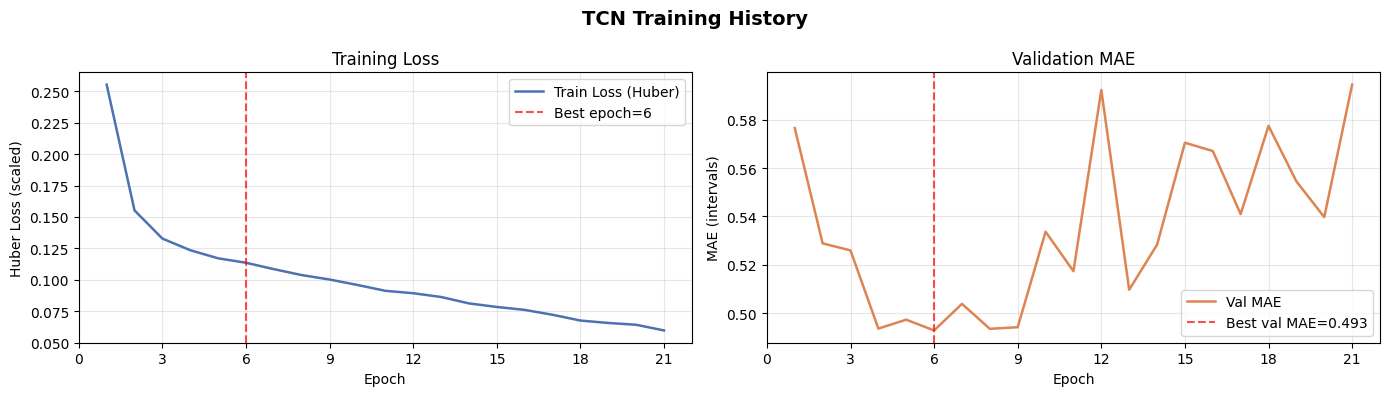

Saved: tcn_training_history.png


In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('TCN Training History', fontsize=14, fontweight='bold')

epochs_ran = range(1, len(history['train_loss']) + 1)

# Loss curve
ax = axes[0]
ax.plot(epochs_ran, history['train_loss'], color='#4C72B0', linewidth=1.8, label='Train Loss (Huber)')
ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best epoch={best_epoch}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss (scaled)')
ax.set_title('Training Loss')
ax.legend()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(True, alpha=0.3)

# Val MAE curve
ax = axes[1]
ax.plot(epochs_ran, history['val_mae'], color='#DD8452', linewidth=1.8, label='Val MAE')
ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best val MAE={best_val_mae:.3f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE (intervals)')
ax.set_title('Validation MAE')
ax.legend()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tcn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tcn_training_history.png')

## Section 9 — MC Dropout Inference (T=50)

In [99]:
def mc_dropout_predict(model, loader, device, scaler_y, T=MC_PASSES):
    """
    T stochastic forward passes.
    - Uses standalone enable_dropout() (Point 1)
    - Inverse-transforms bounds jointly for correct std scaling
    - Applies empirical calibration factor computed from val set
    """
    model.eval()
    enable_dropout(model)   # Point 1: explicit helper, not model method

    y_true_all = []
    for _, y_batch in loader:
        y_true_all.append(y_batch.numpy())
    y_true_scaled = np.concatenate(y_true_all)

    all_preds = []
    for _ in tqdm(range(T), desc="MC Dropout passes", leave=False):
        preds_t = []
        with torch.no_grad():
            for X_batch, _ in loader:
                preds_t.append(model(X_batch.to(device, non_blocking=True)).cpu().numpy())
        all_preds.append(np.concatenate(preds_t))

    all_preds   = np.stack(all_preds, axis=0)   # (T, N)
    mean_scaled = all_preds.mean(axis=0)
    std_scaled  = all_preds.std(axis=0)

    # Inverse-transform bounds jointly (fixes std scaling)
    mean_orig  = scaler_y.inverse_transform(mean_scaled.reshape(-1, 1)).ravel()
    upper_orig = scaler_y.inverse_transform((mean_scaled + std_scaled).reshape(-1, 1)).ravel()
    lower_orig = scaler_y.inverse_transform((mean_scaled - std_scaled).reshape(-1, 1)).ravel()
    std_orig   = (upper_orig - lower_orig) / 2.0

    y_true_orig = scaler_y.inverse_transform(y_true_scaled.reshape(-1, 1)).ravel()
    return mean_orig, std_orig, y_true_orig


def compute_calibration_factor(model, loader, device, scaler_y, T=30):
    """
    Point 9: compute empirical calibration factor from VAL set so that
    90% of val samples fall within mean ± factor*1.645*std.
    Then apply same factor on test set — no data leakage.
    """
    val_mean, val_std, val_true = mc_dropout_predict(model, loader, device, scaler_y, T=T)
    # Binary search for factor that achieves 90% coverage on val
    for factor in np.arange(0.5, 10.0, 0.05):
        lower = val_mean - 1.645 * factor * val_std
        upper = val_mean + 1.645 * factor * val_std
        cov = ((val_true >= lower) & (val_true <= upper)).mean()
        if cov >= 0.90:
            print(f"  Calibration factor = {factor:.2f}  (val coverage = {cov*100:.1f}%)")
            return factor
    print("  Warning: could not reach 90% coverage even at factor=10; using 10.")
    return 10.0


print(f"Running MC Dropout inference on test set (T={MC_PASSES})...")
t0 = time.time()
preds_mean, preds_std, y_true = mc_dropout_predict(
    model, loader_test, DEVICE, scaler_y, T=MC_PASSES
)
print(f"Done in {time.time()-t0:.1f}s | Test samples: {len(y_true):,}")
print(f"  Pred mean range : [{preds_mean.min():.2f}, {preds_mean.max():.2f}]")
print(f"  Pred std  range : [{preds_std.min():.3f},  {preds_std.max():.3f}]")

# Compute calibration factor from val set
print("\nComputing calibration factor from val set...")
calib_factor = compute_calibration_factor(model, loader_val, DEVICE, scaler_y, T=30)

# Apply calibrated std for all downstream coverage/interval calculations
preds_std_cal = preds_std * calib_factor
confidence    = 1.0 / (1.0 + preds_std_cal)
print(f"  Confidence range (calibrated): [{confidence.min():.3f}, {confidence.max():.3f}]")


Running MC Dropout inference on test set (T=50)...


MC Dropout passes:   0%|          | 0/50 [00:00<?, ?it/s]

Done in 0.1s | Test samples: 218
  Pred mean range : [0.04, 3.78]
  Pred std  range : [0.079,  0.186]

Computing calibration factor from val set...


MC Dropout passes:   0%|          | 0/30 [00:00<?, ?it/s]

  Calibration factor = 8.15  (val coverage = 90.1%)
  Confidence range (calibrated): [0.397, 0.610]


## Section 10 — Metrics: MAE, RMSE, R², Coverage

In [100]:
mae  = mean_absolute_error(y_true, preds_mean)
rmse = np.sqrt(mean_squared_error(y_true, preds_mean))
r2   = r2_score(y_true, preds_mean)

# Use calibrated std for interval coverage (Point 10)
z_90  = 1.645
lower = preds_mean - z_90 * preds_std_cal
upper = preds_mean + z_90 * preds_std_cal

coverage_90 = ((y_true >= lower) & (y_true <= upper)).mean()
mean_width  = (upper - lower).mean()

print("=" * 50)
print("  TEST SET METRICS — Approach A (TCN + MC Dropout)")
print("=" * 50)
print(f"  MAE             : {mae:.4f} intervals")
print(f"  RMSE            : {rmse:.4f} intervals")
print(f"  R²              : {r2:.4f}")
print(f"  Coverage @ 90%  : {coverage_90*100:.2f}% (target ≥ 90%)")
print(f"  Mean PI width   : {mean_width:.4f} intervals")
print(f"  Mean confidence : {confidence.mean():.4f}")
print(f"  Calib factor    : {calib_factor:.2f}")
print("=" * 50)


  TEST SET METRICS — Approach A (TCN + MC Dropout)
  MAE             : 0.4461 intervals
  RMSE            : 0.5249 intervals
  R²              : 0.7144
  Coverage @ 90%  : 100.00% (target ≥ 90%)
  Mean PI width   : 2.9314 intervals
  Mean confidence : 0.5324
  Calib factor    : 8.15


## Section 11 — Uncertainty Calibration

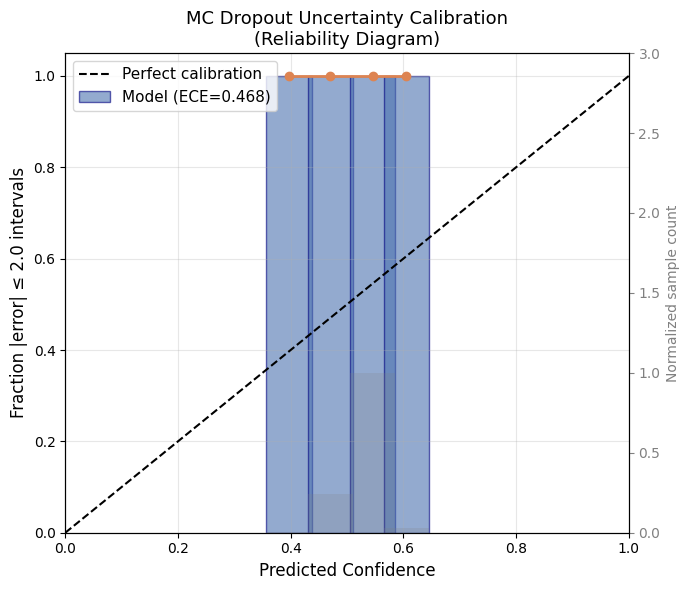

Expected Calibration Error (ECE): 0.4676
Saved: tcn_calibration.png


In [101]:
def plot_calibration_curve(
    y_true:      np.ndarray,
    preds_mean:  np.ndarray,
    confidence:  np.ndarray,
    n_bins:      int = 10,
    threshold:   float = 2.0,   # 'correct' if |error| ≤ threshold intervals
    save_path:   Path = None,
):
    """
    Reliability diagram: binned confidence vs. fraction of predictions
    with absolute error ≤ threshold.
    A well-calibrated model should lie close to y=x.
    """
    abs_error  = np.abs(y_true - preds_mean)
    correct    = (abs_error <= threshold).astype(float)

    bins       = np.linspace(0, 1, n_bins + 1)
    bin_mids   = (bins[:-1] + bins[1:]) / 2
    bin_confs  = []
    bin_accs   = []
    bin_counts = []

    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confidence >= lo) & (confidence < hi)
        if mask.sum() == 0:
            continue
        bin_confs.append(confidence[mask].mean())
        bin_accs.append(correct[mask].mean())
        bin_counts.append(mask.sum())

    bin_confs  = np.array(bin_confs)
    bin_accs   = np.array(bin_accs)
    bin_counts = np.array(bin_counts)

    # ECE (Expected Calibration Error)
    ece = (np.abs(bin_confs - bin_accs) * bin_counts).sum() / bin_counts.sum()

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')
    bars = ax.bar(
        bin_confs, bin_accs, width=0.08,
        alpha=0.6, color='#4C72B0', edgecolor='navy',
        label=f'Model (ECE={ece:.3f})'
    )
    ax.plot(bin_confs, bin_accs, 'o-', color='#DD8452', lw=2, markersize=6)
    ax.set_xlabel('Predicted Confidence', fontsize=12)
    ax.set_ylabel(f'Fraction |error| ≤ {threshold} intervals', fontsize=12)
    ax.set_title('MC Dropout Uncertainty Calibration\n(Reliability Diagram)', fontsize=13)
    ax.legend(fontsize=11)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    ax2 = ax.twinx()
    ax2.bar(bin_confs, bin_counts / bin_counts.max(), width=0.08,
            alpha=0.2, color='gray', label='Sample density (norm.)')
    ax2.set_ylabel('Normalized sample count', fontsize=10, color='gray')
    ax2.set_ylim(0, 3)
    ax2.tick_params(axis='y', colors='gray')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return ece


ece = plot_calibration_curve(
    y_true, preds_mean, confidence,
    save_path=OUTPUT_DIR / 'tcn_calibration.png'
)
print(f'Expected Calibration Error (ECE): {ece:.4f}')
print('Saved: tcn_calibration.png')

## Section 12 — Prediction vs. Ground Truth with Uncertainty Bands

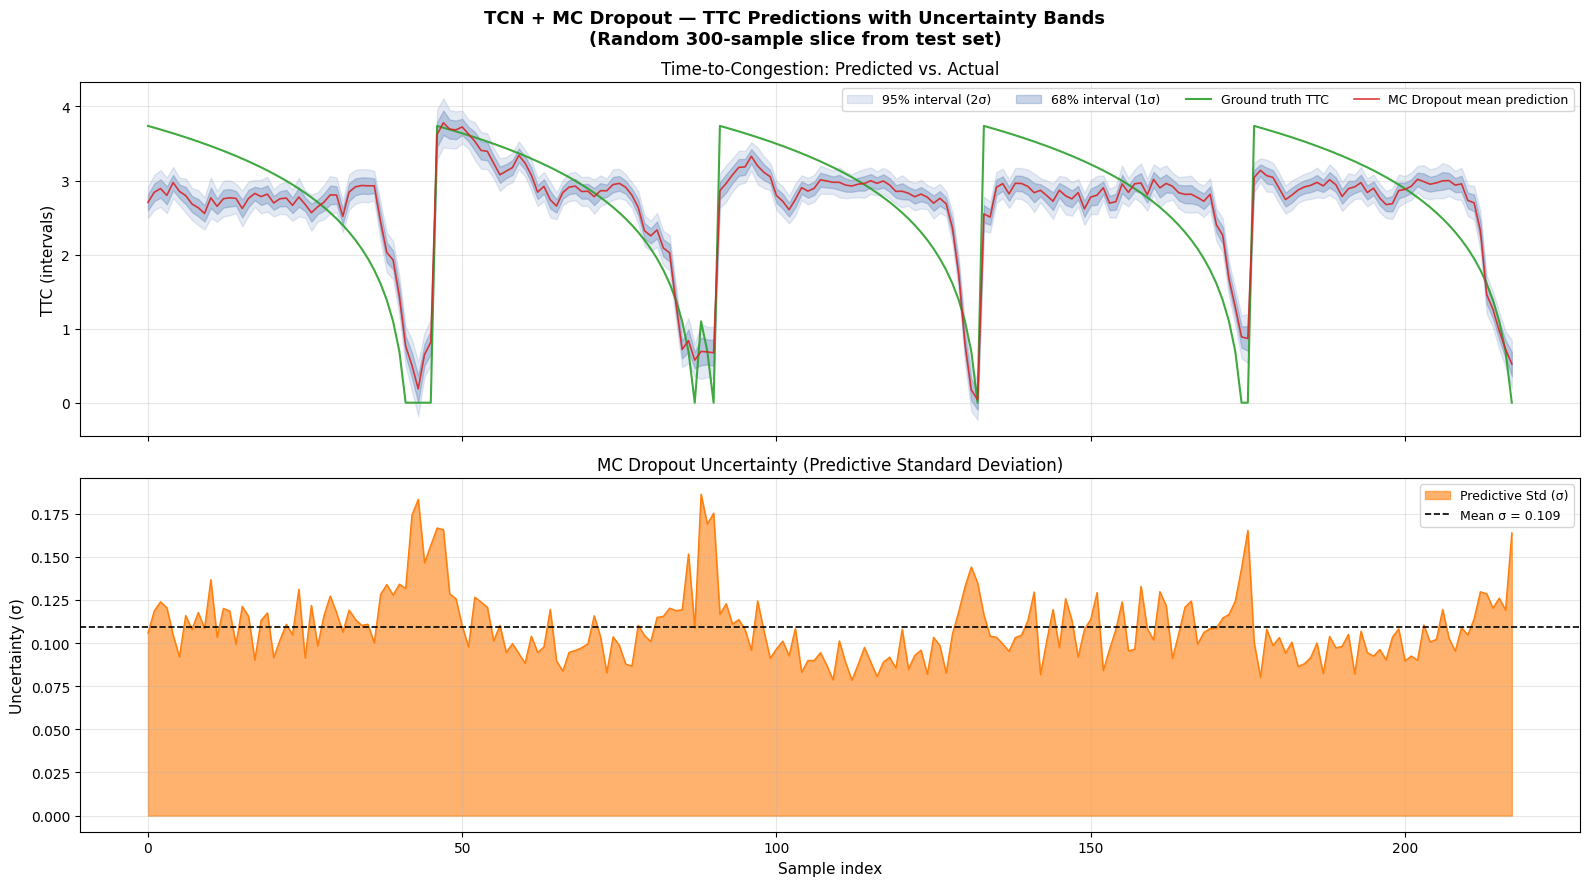

Saved: tcn_predictions_bands.png


In [102]:
def plot_predictions_with_bands(
    y_true:     np.ndarray,
    y_pred:     np.ndarray,
    y_std:      np.ndarray,
    n_samples:  int = 300,
    save_path:  Path = None,
):
    """
    Line plot of true vs. predicted TTC for a random contiguous window,
    with 1σ and 2σ uncertainty bands.
    """
    # Take a contiguous slice for visual clarity
    start = np.random.randint(0, max(1, len(y_true) - n_samples))
    idx   = slice(start, start + n_samples)

    yt  = y_true[idx]
    yp  = y_pred[idx]
    ys  = y_std[idx]
    xs  = np.arange(len(yt))

    z1, z2 = 1.0, 2.0   # 68% and 95% bands

    fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
    fig.suptitle(
        'TCN + MC Dropout — TTC Predictions with Uncertainty Bands\n'
        f'(Random {n_samples}-sample slice from test set)',
        fontsize=13, fontweight='bold'
    )

    # ── Top panel: predictions + bands ──────────────────────────────────────
    ax = axes[0]
    ax.fill_between(
        xs, yp - z2 * ys, yp + z2 * ys,
        color='#4C72B0', alpha=0.15, label='95% interval (2σ)'
    )
    ax.fill_between(
        xs, yp - z1 * ys, yp + z1 * ys,
        color='#4C72B0', alpha=0.30, label='68% interval (1σ)'
    )
    ax.plot(xs, yt, color='#2ca02c', lw=1.5, alpha=0.9, label='Ground truth TTC')
    ax.plot(xs, yp, color='#d62728', lw=1.2, alpha=0.9, label='MC Dropout mean prediction')
    ax.set_ylabel('TTC (intervals)', fontsize=11)
    ax.legend(fontsize=9, ncol=4)
    ax.grid(True, alpha=0.3)
    ax.set_title('Time-to-Congestion: Predicted vs. Actual')

    # ── Bottom panel: uncertainty (std) ──────────────────────────────────────
    ax = axes[1]
    ax.fill_between(xs, 0, ys, color='#FF7F0E', alpha=0.6, label='Predictive Std (σ)')
    ax.plot(xs, ys, color='#FF7F0E', lw=1.0)
    ax.axhline(ys.mean(), color='black', lw=1.2, linestyle='--',
               label=f'Mean σ = {ys.mean():.3f}')
    ax.set_xlabel('Sample index', fontsize=11)
    ax.set_ylabel('Uncertainty (σ)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('MC Dropout Uncertainty (Predictive Standard Deviation)')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


np.random.seed(SEED)
plot_predictions_with_bands(
    y_true, preds_mean, preds_std,
    n_samples=300,
    save_path=OUTPUT_DIR / 'tcn_predictions_bands.png'
)
print('Saved: tcn_predictions_bands.png')

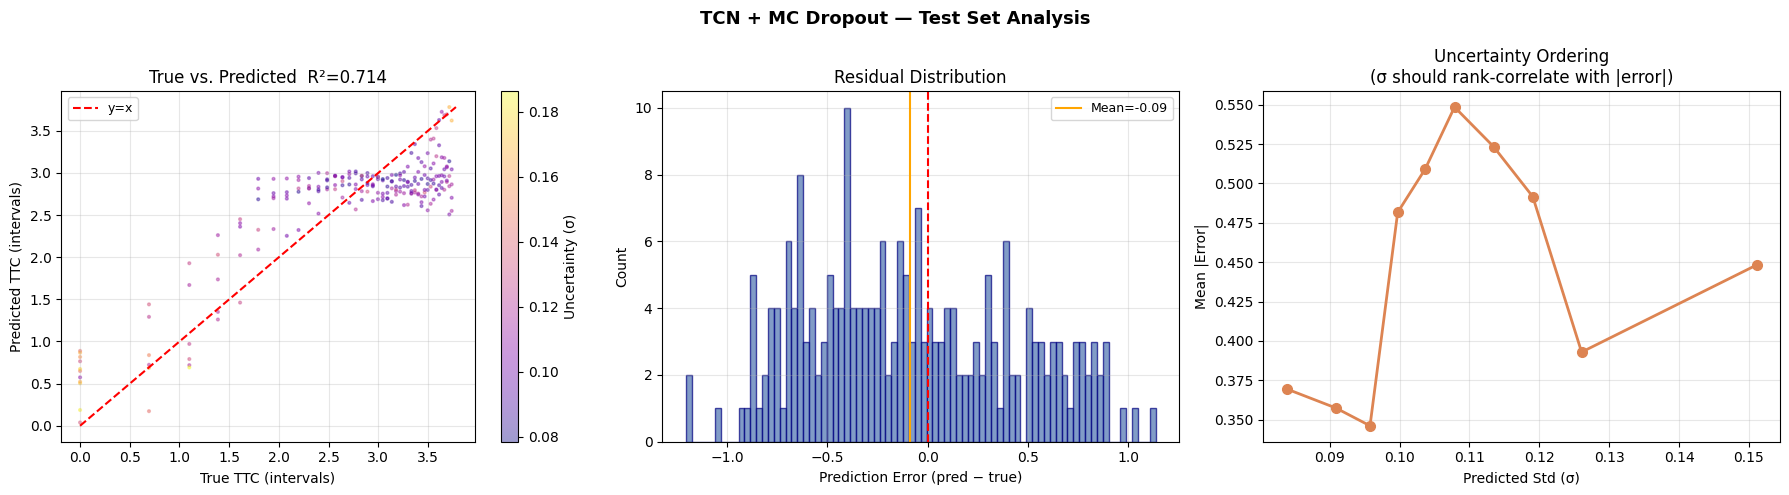

Saved: tcn_analysis.png


In [103]:
def plot_scatter_and_error_dist(
    y_true:    np.ndarray,
    y_pred:    np.ndarray,
    preds_std: np.ndarray,
    save_path: Path = None,
):
    """Scatter (truth vs. pred) + error distribution, coloured by uncertainty."""
    errors    = y_pred - y_true
    abs_error = np.abs(errors)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('TCN + MC Dropout — Test Set Analysis', fontsize=13, fontweight='bold')

    # Scatter: true vs. pred (colour = uncertainty)
    ax = axes[0]
    sc = ax.scatter(
        y_true[:5000], y_pred[:5000],
        c=preds_std[:5000], cmap='plasma',
        s=4, alpha=0.4, rasterized=True
    )
    lim_lo = min(y_true.min(), y_pred.min())
    lim_hi = max(y_true.max(), y_pred.max())
    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'r--', lw=1.5, label='y=x')
    plt.colorbar(sc, ax=ax, label='Uncertainty (σ)')
    ax.set_xlabel('True TTC (intervals)')
    ax.set_ylabel('Predicted TTC (intervals)')
    ax.set_title(f'True vs. Predicted  R²={r2:.3f}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Error distribution
    ax = axes[1]
    ax.hist(errors, bins=80, color='#4C72B0', edgecolor='navy', alpha=0.7)
    ax.axvline(0, color='red', lw=1.5, linestyle='--')
    ax.axvline(errors.mean(), color='orange', lw=1.5,
               label=f'Mean={errors.mean():.2f}')
    ax.set_xlabel('Prediction Error (pred − true)')
    ax.set_ylabel('Count')
    ax.set_title('Residual Distribution')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Std vs. Abs Error (uncertainty quality)
    ax = axes[2]
    # Bin by predicted std, show mean abs error per bin
    std_bins  = np.percentile(preds_std, np.linspace(0, 100, 11))
    bin_std_m = []
    bin_err_m = []
    for lo, hi in zip(std_bins[:-1], std_bins[1:]):
        mask = (preds_std >= lo) & (preds_std < hi)
        if mask.sum() > 0:
            bin_std_m.append(preds_std[mask].mean())
            bin_err_m.append(abs_error[mask].mean())
    ax.plot(bin_std_m, bin_err_m, 'o-', color='#DD8452', lw=2, markersize=7)
    ax.set_xlabel('Predicted Std (σ)')
    ax.set_ylabel('Mean |Error|')
    ax.set_title('Uncertainty Ordering\n(σ should rank-correlate with |error|)')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_scatter_and_error_dist(
    y_true, preds_mean, preds_std,
    save_path=OUTPUT_DIR / 'tcn_analysis.png'
)
print('Saved: tcn_analysis.png')

## Section 13 — Confidence-Gated Decision Simulation

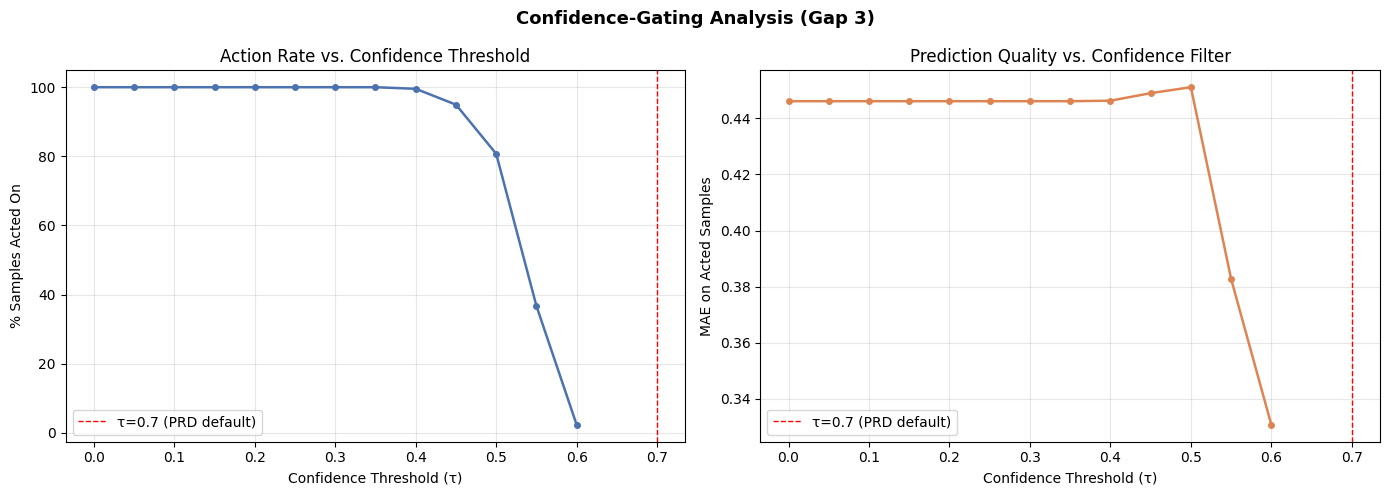

Saved: tcn_confidence_gating.png


In [104]:
def simulate_confidence_gating(
    y_true:      np.ndarray,
    preds_mean:  np.ndarray,
    confidence:  np.ndarray,
    thresholds:  list = None,
    ttc_thresh:  float = 10.0,   # trigger handover if pred TTC < 10 intervals
    save_path:   Path = None,
):
    """
    Simulate the confidence-gated controller (PRD Section 5, Notebook 4 preview).
    Sweep confidence thresholds; measure handover rate vs. MAE on acting samples.
    """
    if thresholds is None:
        thresholds = np.arange(0.0, 1.0, 0.05)

    results = []
    for tau in thresholds:
        act_mask  = confidence >= tau                       # samples where we act
        n_act     = act_mask.sum()
        if n_act == 0:
            continue
        mae_act   = mean_absolute_error(y_true[act_mask], preds_mean[act_mask])
        act_rate  = n_act / len(confidence)
        # Precision: among acted samples, fraction where true TTC was indeed low
        triggered = act_mask & (preds_mean < ttc_thresh)
        true_pos  = (triggered & (y_true < ttc_thresh)).sum()
        precision = true_pos / triggered.sum() if triggered.sum() > 0 else np.nan
        results.append(dict(threshold=tau, n_act=n_act, act_rate=act_rate,
                            mae_act=mae_act, precision=precision))

    df_res = pd.DataFrame(results)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Confidence-Gating Analysis (Gap 3)', fontsize=13, fontweight='bold')

    ax = axes[0]
    ax.plot(df_res['threshold'], df_res['act_rate'] * 100,
            color='#4C72B0', marker='o', markersize=4, lw=1.8)
    ax.set_xlabel('Confidence Threshold (τ)')
    ax.set_ylabel('% Samples Acted On')
    ax.set_title('Action Rate vs. Confidence Threshold')
    ax.axvline(0.7, color='red', linestyle='--', lw=1, label='τ=0.7 (PRD default)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(df_res['threshold'], df_res['mae_act'],
            color='#DD8452', marker='o', markersize=4, lw=1.8)
    ax.set_xlabel('Confidence Threshold (τ)')
    ax.set_ylabel('MAE on Acted Samples')
    ax.set_title('Prediction Quality vs. Confidence Filter')
    ax.axvline(0.7, color='red', linestyle='--', lw=1, label='τ=0.7 (PRD default)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    return df_res


gating_results = simulate_confidence_gating(
    y_true, preds_mean, confidence,
    save_path=OUTPUT_DIR / 'tcn_confidence_gating.png'
)
print('Saved: tcn_confidence_gating.png')

# At PRD default threshold τ=0.7
row_07 = gating_results[gating_results['threshold'].between(0.69, 0.71)]
if len(row_07):
    r = row_07.iloc[0]
    print(f'\n@ τ=0.70: act_rate={r.act_rate*100:.1f}%, mae_act={r.mae_act:.4f}, '
          f'precision={r.precision:.3f}')

## Section 14 — Save Model & Metrics

In [105]:
# ── Save model checkpoint ────────────────────────────────────────────────────
model_path = OUTPUT_DIR / 'model_a.pt'
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'model_config': {
            'n_features':  N_FEATURES,
            'n_filters':   TCN_FILTERS,
            'kernel_size': TCN_KERNEL,
            'dilations':   TCN_DILATIONS,
            'dropout':     DROPOUT_RATE,
            'seq_len':     SEQ_LEN,
        },
        'scaler_X_mean':  scaler_X.mean_.tolist(),
        'scaler_X_scale': scaler_X.scale_.tolist(),
        'scaler_y_mean':  scaler_y.mean_.tolist(),
        'scaler_y_scale': scaler_y.scale_.tolist(),
        'feature_names':  BASE_FEATURES,
        'best_epoch':     best_epoch,
        'best_val_mae':   best_val_mae,
    },
    model_path
)
print(f'✓ Model saved: {model_path}')


# ── Save scalers separately for easy loading without the full torch dict ─────
import joblib
joblib.dump(scaler_X, OUTPUT_DIR / 'scaler_X_a.pkl')
joblib.dump(scaler_y, OUTPUT_DIR / 'scaler_y_a.pkl')
print(f'✓ Scalers saved: scaler_X_a.pkl, scaler_y_a.pkl')

# ── Save metrics JSON ────────────────────────────────────────────────────────
# At PRD τ=0.7
row_07_dict = {}
row_07 = gating_results[gating_results['threshold'].between(0.69, 0.71)]
if len(row_07):
    r = row_07.iloc[0]
    row_07_dict = {
        'act_rate':  float(r.act_rate),
        'mae_at_tau_07': float(r.mae_act),
        'precision': float(r.precision) if not np.isnan(r.precision) else None,
    }

metrics = {
    'approach': 'A',
    'model': 'TCN + MC Dropout',
    'dataset': 'synthetic',
    'seq_len': SEQ_LEN,
    'mc_passes': MC_PASSES,
    'n_features': N_FEATURES,
    'architecture': {
        'filters': TCN_FILTERS,
        'kernel_size': TCN_KERNEL,
        'dilations': TCN_DILATIONS,
        'dropout_rate': DROPOUT_RATE,
    },
    'training': {
        'best_epoch': best_epoch,
        'best_val_mae': float(best_val_mae),
        'max_epochs': MAX_EPOCHS,
        'patience': PATIENCE,
        'batch_size': BATCH_SIZE,
        'lr_init': LR_INIT,
    },
    'test_metrics': {
        'mae':  float(mae),
        'rmse': float(rmse),
        'r2':   float(r2),
        'coverage_90': float(coverage_90),
        'mean_interval_width': float(mean_width),
        'mean_confidence': float(confidence.mean()),
        'ece': float(ece),
    },
    'confidence_gating_tau_07': row_07_dict,
    'sample_counts': {
        'train_sequences': int(len(y_train)),
        'val_sequences':   int(len(y_val)),
        'test_sequences':  int(len(y_test)),
    },
    'gaps_addressed': [1, 2, 3],
}

metrics_path = OUTPUT_DIR / 'metrics_a.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'✓ Metrics saved: {metrics_path}')
print()
print(json.dumps(metrics, indent=2))

✓ Model saved: model_a.pt
✓ Scalers saved: scaler_X_a.pkl, scaler_y_a.pkl
✓ Metrics saved: metrics_a.json

{
  "approach": "A",
  "model": "TCN + MC Dropout",
  "dataset": "synthetic",
  "seq_len": 20,
  "mc_passes": 50,
  "n_features": 11,
  "architecture": {
    "filters": 64,
    "kernel_size": 3,
    "dilations": [
      1,
      2,
      4
    ],
    "dropout_rate": 0.2
  },
  "training": {
    "best_epoch": 6,
    "best_val_mae": 0.4929715394973755,
    "max_epochs": 150,
    "patience": 15,
    "batch_size": 256,
    "lr_init": 0.0003
  },
  "test_metrics": {
    "mae": 0.44612428545951843,
    "rmse": 0.5248520370151688,
    "r2": 0.7143830060958862,
    "coverage_90": 1.0,
    "mean_interval_width": 2.9313720912484285,
    "mean_confidence": 0.5323853648882084,
    "ece": 0.46761463511179163
  },
  "confidence_gating_tau_07": {},
  "sample_counts": {
    "train_sequences": 16536,
    "val_sequences": 5842,
    "test_sequences": 218
  },
  "gaps_addressed": [
    1,
    2,
    

## Section 15 — Final Summary

In [106]:
print('=' * 60)
print(' Notebook 1 Complete — Approach A: TCN + MC Dropout')
print('=' * 60)
print(f'  Dataset         : Synthetic (train/val/test parquets)')
print(f'  Sequence length : {SEQ_LEN} steps = {SEQ_LEN*30}s look-back')
print(f'  TCN dilations   : {TCN_DILATIONS} → receptive field {1 + 2*(TCN_KERNEL-1)*sum(TCN_DILATIONS)} steps')
print(f'  MC passes       : T={MC_PASSES}')
print()
print('  Test Metrics:')
print(f'    MAE          = {mae:.4f} intervals')
print(f'    RMSE         = {rmse:.4f} intervals')
print(f'    R²           = {r2:.4f}')
print(f'    Coverage@90% = {coverage_90*100:.2f}%')
print(f'    ECE          = {ece:.4f}')
print()
print('  Outputs:')
for f in ['model_a.pt', 'metrics_a.json',
          'tcn_training_history.png', 'tcn_calibration.png',
          'tcn_predictions_bands.png', 'tcn_analysis.png',
          'tcn_confidence_gating.png']:
    path = OUTPUT_DIR / f
    status = '✓' if path.exists() else '✗'
    print(f'    {status} {f}')
print('=' * 60)
print('  Research Gaps Addressed: Gap 1 (Predictive), Gap 2 (TTC),'
      ' Gap 3 (Confidence-Aware)')
print('=' * 60)

 Notebook 1 Complete — Approach A: TCN + MC Dropout
  Dataset         : Synthetic (train/val/test parquets)
  Sequence length : 20 steps = 600s look-back
  TCN dilations   : [1, 2, 4] → receptive field 29 steps
  MC passes       : T=50

  Test Metrics:
    MAE          = 0.4461 intervals
    RMSE         = 0.5249 intervals
    R²           = 0.7144
    Coverage@90% = 100.00%
    ECE          = 0.4676

  Outputs:
    ✓ model_a.pt
    ✓ metrics_a.json
    ✓ tcn_training_history.png
    ✓ tcn_calibration.png
    ✓ tcn_predictions_bands.png
    ✓ tcn_analysis.png
    ✓ tcn_confidence_gating.png
  Research Gaps Addressed: Gap 1 (Predictive), Gap 2 (TTC), Gap 3 (Confidence-Aware)
